# 1 - Inicialização

In [644]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import datetime as dt
from scipy import stats
import math as mth
from scipy import stats as st

In [645]:
# Nesse projeto será adotado para o nível de significância o valor de 0.05
alpha = 0.05 # nível de significância

# 2 - Carregando os dados

In [646]:
hypotheses = pd.read_csv('/datasets/hypotheses_us.csv', sep=';')

In [647]:
orders = pd.read_csv('/datasets/orders_us.csv')

In [648]:
visits = pd.read_csv('/datasets/visits_us.csv')

## 2.1 - Analisando os DF

### 2.1.1 - hypotheses

In [649]:
hypotheses.columns = hypotheses.columns.str.lower()

In [650]:
hypotheses.head(4)

,hypothesis,reach,impact,confidence,effort
0,Add two new channels for attracting traffic. T...,3,10,8,6
1,Launch your own delivery service. This will sh...,2,5,4,10
2,Add product recommendation blocks to the store...,8,3,7,3
3,Change the category structure. This will incre...,8,3,3,8


### 2.1.2 - orders

In [651]:
# Alterar o tipo da coluna date
orders['date'] = pd.to_datetime(orders['date'])

In [652]:
# Verificar se há usuários nos dois grupos
users_A = set(orders[orders['group'] == 'A']['visitorId'])
users_B = set(orders[orders['group'] == 'B']['visitorId'])

In [653]:
# Usuários que aparecem nos dois grupos
duplicated_users = users_A.intersection(users_B)
print(f"Usuários em ambos os grupos: {len(duplicated_users)}")

Usuários em ambos os grupos: 58


In [654]:
# Remover usuários que aparecem nos dois grupos
clean_orders = orders[~orders['visitorId'].isin(duplicated_users)]

In [655]:
clean_orders.head()

,transactionId,visitorId,date,revenue,group
0,3667963787,3312258926,2019-08-15,30.4,B
1,2804400009,3642806036,2019-08-15,15.2,B
3,3797467345,1196621759,2019-08-15,155.1,B
4,2282983706,2322279887,2019-08-15,40.5,B
5,182168103,935554773,2019-08-15,35.0,B


### 2.1.3 - visits

In [656]:
visits.head()

,date,group,visits
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507
3,2019-08-04,A,717
4,2019-08-05,A,756


In [657]:
# Alterar o tipo da coluna date
visits['date'] = pd.to_datetime(visits['date'])

# 3 - Priorizando Hipóteses

## 3.1 - ICE

In [658]:
hypotheses

,hypothesis,reach,impact,confidence,effort
0,Add two new channels for attracting traffic. T...,3,10,8,6
1,Launch your own delivery service. This will sh...,2,5,4,10
2,Add product recommendation blocks to the store...,8,3,7,3
3,Change the category structure. This will incre...,8,3,3,8
4,Change the background color on the main page. ...,3,1,1,1
5,Add a customer review page. This will increase...,3,2,2,3
6,Show banners with current offers and sales on ...,5,3,8,3
7,Add a subscription form to all the main pages....,10,7,8,5
8,Launch a promotion that gives users discounts ...,1,9,9,5


In [659]:
# ICE (impact, confidence, effort)

# ICE_score = (impact x confidence) / effort
hypotheses['ICE_score'] = (hypotheses['impact'] * hypotheses['confidence']) / hypotheses['effort']
print(hypotheses[['hypothesis','ICE_score']].sort_values(by='ICE_score', ascending=False))

                                          hypothesis  ICE_score
8  Launch a promotion that gives users discounts ...  16.200000
0  Add two new channels for attracting traffic. T...  13.333333
7  Add a subscription form to all the main pages....  11.200000
6  Show banners with current offers and sales on ...   8.000000
2  Add product recommendation blocks to the store...   7.000000
1  Launch your own delivery service. This will sh...   2.000000
5  Add a customer review page. This will increase...   1.333333
3  Change the category structure. This will incre...   1.125000
4  Change the background color on the main page. ...   1.000000


As hipóteses mais **promissoras** são: **8**, **0**, **7** e **6**.

In [660]:
# RICE (reach, impact, confidence, effort)

#RICE_score = (reach x impact x confidence) / effort
hypotheses['RICE_score'] = (hypotheses['reach'] * hypotheses['impact'] * hypotheses['confidence']) / hypotheses['effort']
print(hypotheses[['hypothesis','RICE_score']].sort_values(by='RICE_score', ascending=False))

                                          hypothesis  RICE_score
7  Add a subscription form to all the main pages....       112.0
2  Add product recommendation blocks to the store...        56.0
0  Add two new channels for attracting traffic. T...        40.0
6  Show banners with current offers and sales on ...        40.0
8  Launch a promotion that gives users discounts ...        16.2
3  Change the category structure. This will incre...         9.0
1  Launch your own delivery service. This will sh...         4.0
5  Add a customer review page. This will increase...         4.0
4  Change the background color on the main page. ...         3.0


Percebe-se uma alteração quanto a posição das hipóteses, tornando as **hipóteses 7 e 2 mais promissoras**. 

Isso porque seu parâmetro 'reach' é 10 e 8 respectivamente, enquanto as outras hipóteses possuem valaores menores.

**Considera-se não apenas a robustez da hipótese, mas também o número de usuários afetados**.

## 4 - Análise de teste A/B

## 4.1 - Receita acumulada por grupo

In [661]:
# Calcular receita acumulada por data e grupo
revenue_cumulative = clean_orders.groupby(['date', 'group'])['revenue'].sum().reset_index()
revenue_cumulative = revenue_cumulative.pivot(index='date', columns='group', values='revenue').fillna(0)
revenue_cumulative = revenue_cumulative.cumsum()

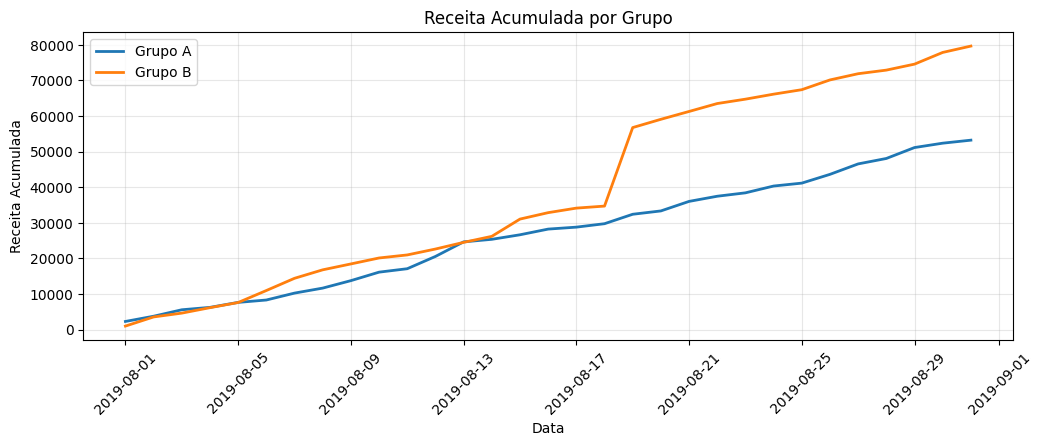

In [662]:
# imprimir o gráfico da receita acumulada
plt.figure(figsize=(12, 4))
plt.plot(revenue_cumulative.index, revenue_cumulative['A'], label='Grupo A', linewidth=2)
plt.plot(revenue_cumulative.index, revenue_cumulative['B'], label='Grupo B', linewidth=2)
plt.title('Receita Acumulada por Grupo')
plt.xlabel('Data')
plt.ylabel('Receita Acumulada')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.show()

1 - Grupo B apresenta melhor desempenho geral

2 - Existe um evento atipico no meio do período

    * Há um salto abrupto na receita do Grupo B por volta da data 2019-08-17
    * Possíveis causas: campanha promocional, entrada de grandes clientes, datas comemorativas
    
3 - Grupo A apresenta crescimento mais estável (linear)

## 4.2 - Tamanho médio acumulado do pedido por grupo

In [663]:
# Agrupar por data e grupo, calcular receita e contagem de pedidos
daily_stats = clean_orders.groupby(['date', 'group']).agg({'revenue': 'sum','transactionId': 'count'}).reset_index()

In [664]:
# Renomear colunas
daily_stats.columns = ['date', 'group', 'daily_revenue', 'daily_orders']

In [665]:
# Calcular receita e pedidos acumulados
daily_stats = daily_stats.sort_values(['group', 'date'])
daily_stats['cumulative_revenue'] = daily_stats.groupby('group')['daily_revenue'].cumsum()
daily_stats['cumulative_orders'] = daily_stats.groupby('group')['daily_orders'].cumsum()

In [666]:
# Calcular tamanho médio acumulado do pedido
daily_stats['avg_order_size_cumulative'] = daily_stats['cumulative_revenue'] / daily_stats['cumulative_orders']

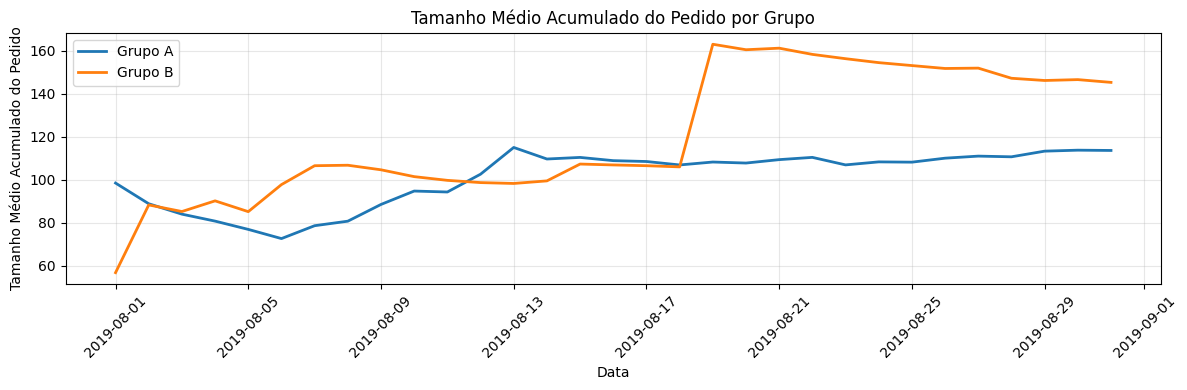

In [667]:
plt.figure(figsize=(12, 4))

# Filtrar dados por grupo
group_A = daily_stats[daily_stats['group'] == 'A']
group_B = daily_stats[daily_stats['group'] == 'B']

# imprimir o gráfico
plt.plot(group_A['date'], group_A['avg_order_size_cumulative'], label='Grupo A', linewidth=2)
plt.plot(group_B['date'], group_B['avg_order_size_cumulative'], label='Grupo B', linewidth=2)

plt.title('Tamanho Médio Acumulado do Pedido por Grupo')
plt.xlabel('Data')
plt.ylabel('Tamanho Médio Acumulado do Pedido')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

1 - Grupo B apresente ticket médio maior na maior parte do período

2 - Há um salto abrupto no tamanho do pedido do Grupo B por volta da data 2019-08-17

## 4.3 - Diferença relativa no tamanho médio acumuldo do pedido para o grupo B em comparação com o grupo A

In [668]:
# Preparar dados para o gráfico
pivot_data = daily_stats.pivot(index='date', columns='group', values='avg_order_size_cumulative')

In [669]:
# Calcular diferença relativa (B em relação a A)
pivot_data['relative_diff'] = (pivot_data['B'] - pivot_data['A']) / pivot_data['A'] * 100

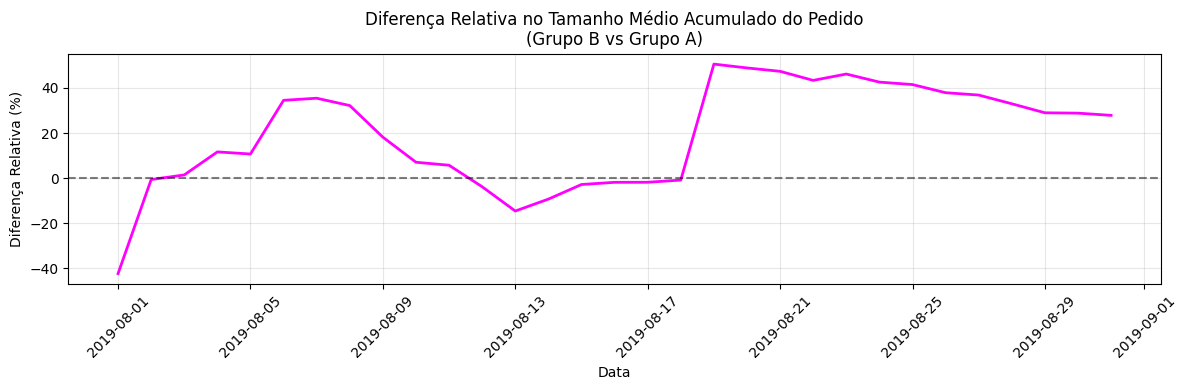

In [670]:
# Criar o gráfico
plt.figure(figsize=(12, 4))
plt.plot(pivot_data.index, pivot_data['relative_diff'], linewidth=2, color='magenta')
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)  # Linha de referência
plt.title('Diferença Relativa no Tamanho Médio Acumulado do Pedido\n(Grupo B vs Grupo A)')
plt.xlabel('Data')
plt.ylabel('Diferença Relativa (%)')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4.4 - Taxa de conversão 

In [671]:
# Juntar os dados de pedidos e visitas
conversion_data = visits.merge(
    daily_stats[['date', 'group', 'daily_orders']], 
    on=['date', 'group'], 
    how='left'
)

In [672]:
# Preencher valores nulos (dias sem pedidos) com 0
conversion_data['daily_orders'] = conversion_data['daily_orders'].fillna(0)

In [673]:
# Calcular taxa de conversão diária
conversion_data['conversion_rate'] = (conversion_data['daily_orders'] / conversion_data['visits']) * 100

In [674]:
# Filtrar por grupo
group_A_conv = conversion_data[conversion_data['group'] == 'A']
group_B_conv = conversion_data[conversion_data['group'] == 'B']

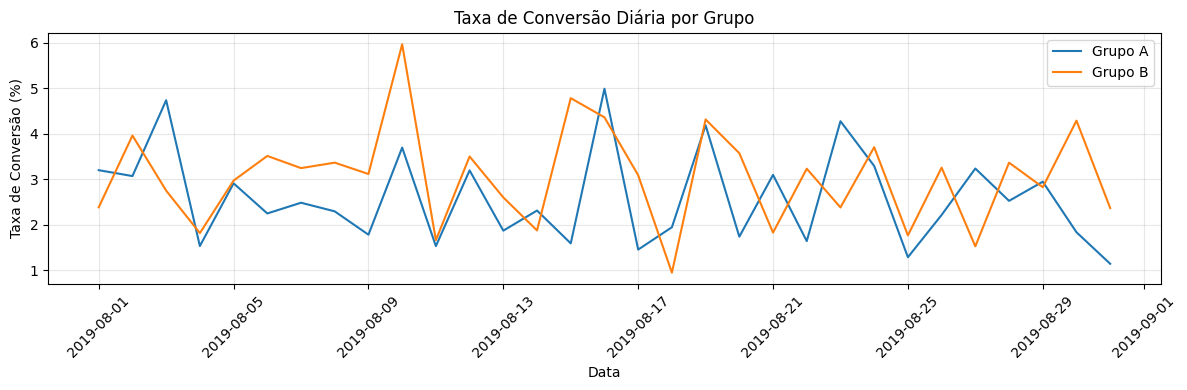

In [675]:
# Plotar as taxas de conversão
plt.figure(figsize=(12, 4))
plt.plot(group_A_conv['date'], group_A_conv['conversion_rate'], label='Grupo A')
plt.plot(group_B_conv['date'], group_B_conv['conversion_rate'], label='Grupo B')
plt.title('Taxa de Conversão Diária por Grupo')
plt.xlabel('Data')
plt.ylabel('Taxa de Conversão (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

1 - Desempenho médio semelhante entre os grupos

## 4.5 - Diferença relativa de conversão cumulativa para o grupo B em comparação com o grupo A

In [676]:
conversion_data.head(2)

,date,group,visits,daily_orders,conversion_rate
0,2019-08-01,A,719,23,3.198887
1,2019-08-02,A,619,19,3.069467


In [677]:
# Ordenar os dados por grupo e data
conversion_data = conversion_data.sort_values(['group', 'date'])

In [678]:
# Calcular visitas e pedidos acumulados por grupo
conversion_data['cumulative_visits'] = conversion_data.groupby('group')['visits'].cumsum()
conversion_data['cumulative_orders'] = conversion_data.groupby('group')['daily_orders'].cumsum()

In [679]:
# Calcular taxa de conversão cumulativa
conversion_data['cumulative_conversion_rate'] = (conversion_data['cumulative_orders'] / conversion_data['cumulative_visits']) * 100

In [680]:
# Criar pivot table com as conversões cumulativas
conversion_pivot = conversion_data.pivot(index='date', columns='group', values='cumulative_conversion_rate')

In [681]:
# Calcular diferença relativa (B em relação a A)
conversion_pivot['relative_diff'] = (conversion_pivot['B'] - conversion_pivot['A']) / conversion_pivot['A'] * 100

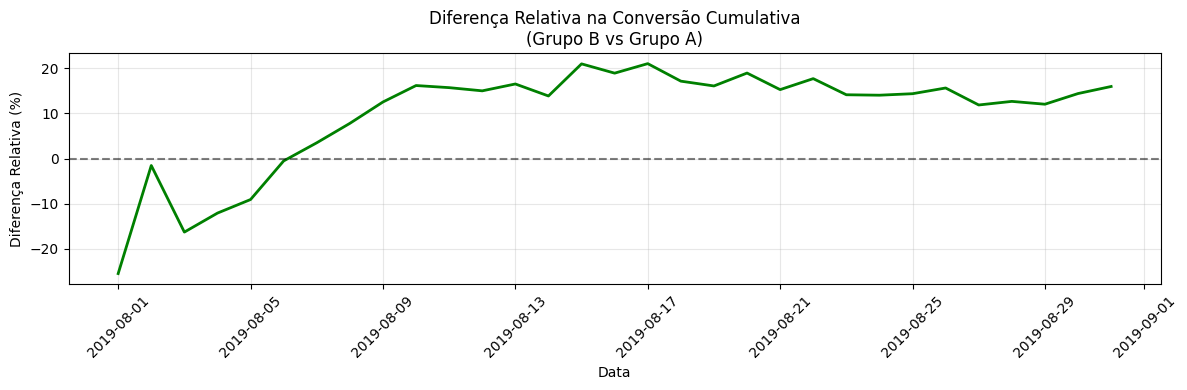

In [682]:
# Criar o gráfico
plt.figure(figsize=(12, 4))
plt.plot(conversion_pivot.index, conversion_pivot['relative_diff'], linewidth=2, color='green')
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)  # Linha de referência
plt.title('Diferença Relativa na Conversão Cumulativa\n(Grupo B vs Grupo A)')
plt.xlabel('Data')
plt.ylabel('Diferença Relativa (%)')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

1 - O grupo B apresenta desempenho cumulativo superior ao Grupo A na maior parte do experimento.

## 4.6 - Percentis 95 e 99 para o número de pedidos por usuário

In [683]:
# Agrupar por usuário
orders_per_user = clean_orders.groupby('visitorId').size()

In [684]:
# Calculando o percentil
percentil_95 = np.percentile(orders_per_user, 95)
percentil_99 = np.percentile(orders_per_user, 99)

In [685]:
print(f"Percentil 95: {percentil_95}")
print(f"Percentil 99: {percentil_99}")

Percentil 95: 1.0
Percentil 99: 2.0


In [686]:
# Verificar a distribuição completa
print("Distribuição de pedidos por usuário:")
print(orders_per_user.value_counts().sort_index())

Distribuição de pedidos por usuário:
1    937
2     29
3      7
dtype: int64


In [687]:
# Informações
print(f"Média: {orders_per_user.mean():.2f}")
print(f"Mediana: {orders_per_user.median()}")
print(f"Máximo: {orders_per_user.max()}")

Média: 1.04
Mediana: 1.0
Máximo: 3


In [688]:
# Definir limite de anomalia
limit = percentil_99
print(f"Limite de anomalia: {limit} pedidos")

# Identificar usuários anômalos
anomalous_users = orders_per_user[orders_per_user > limit]
print(f"Número de usuários anômalos: {len(anomalous_users)}")
print(f"Porcentagem de usuários anômalos: {len(anomalous_users)/len(orders_per_user)*100:.2f}%")

Limite de anomalia: 2.0 pedidos
Número de usuários anômalos: 7
Porcentagem de usuários anômalos: 0.72%


Usuários com mais de 2 pedidos são considerados anomalias (7 usuários).

## 4.7 - Gráfico do preço dos pedidos

In [689]:
clean_orders.head(3)

,transactionId,visitorId,date,revenue,group
0,3667963787,3312258926,2019-08-15,30.4,B
1,2804400009,3642806036,2019-08-15,15.2,B
3,3797467345,1196621759,2019-08-15,155.1,B


In [690]:
grupo_A = clean_orders[clean_orders['group'] == 'A'][['date','revenue']]

In [691]:
grupo_B = clean_orders[clean_orders['group'] == 'B'][['date','revenue']]

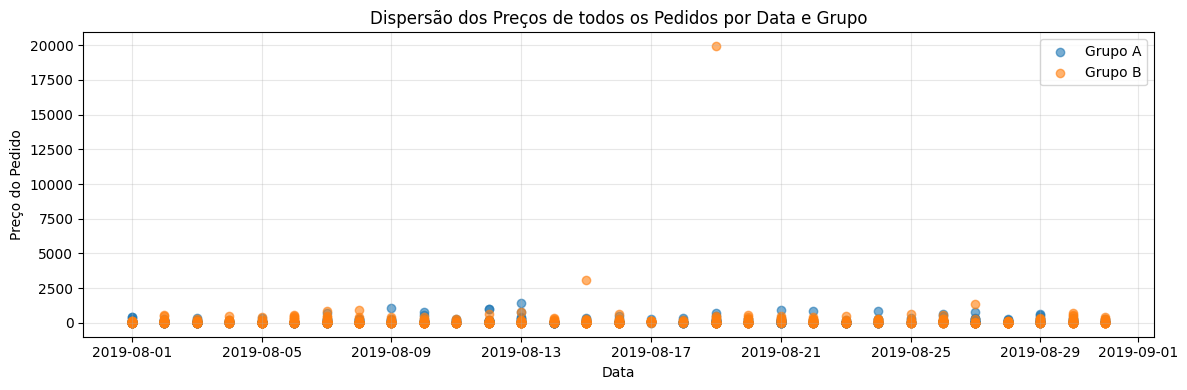

In [692]:
# Criar o gráfico
plt.figure(figsize=(12, 4))
plt.scatter(grupo_A['date'], grupo_A['revenue'], alpha=0.6, label='Grupo A')
plt.scatter(grupo_B['date'], grupo_B['revenue'], alpha=0.6, label='Grupo B')
plt.title('Dispersão dos Preços de todos os Pedidos por Data e Grupo')
plt.xlabel('Data')
plt.ylabel('Preço do Pedido')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

A visualização não ficou clara, portanto a seguir será exibido um gráfico no qual os valores serão somados por dia.

Será apresentado um valor para cada grupo por dia.

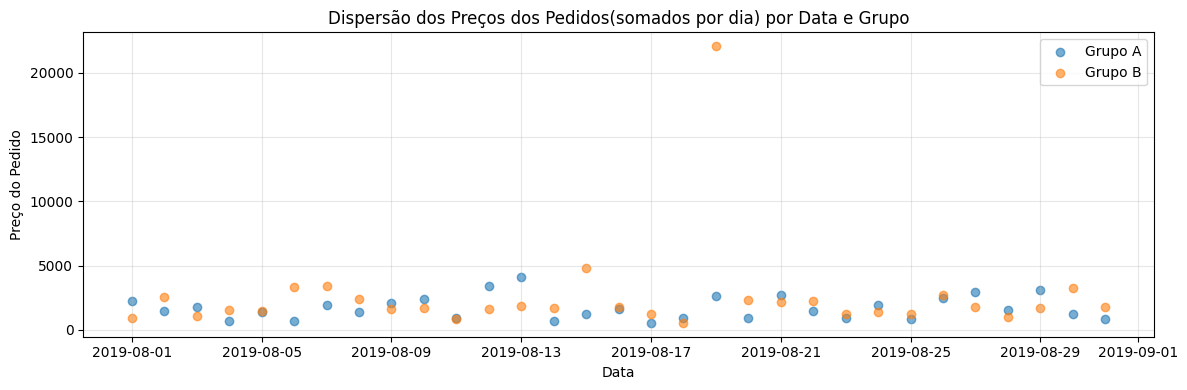

In [693]:
# Criar o gráfico
plt.figure(figsize=(12, 4))
plt.scatter(group_A['date'], group_A['daily_revenue'], alpha=0.6, label='Grupo A')
plt.scatter(group_B['date'], group_B['daily_revenue'], alpha=0.6, label='Grupo B')
plt.title('Dispersão dos Preços dos Pedidos(somados por dia) por Data e Grupo')
plt.xlabel('Data')
plt.ylabel('Preço do Pedido')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4.8 - Percentis 95 e 99 dos preços dos pedidos

In [694]:
# Calcular o percentil
percentil_95_revenue = np.percentile(clean_orders['revenue'], 95)
percentil_99_revenue = np.percentile(clean_orders['revenue'], 99)

In [695]:
print(f"Percentil 95: {percentil_95_revenue:.2f}")
print(f"Percentil 99: {percentil_99_revenue:.2f}")

Percentil 95: 414.27
Percentil 99: 830.30


In [696]:
# Informações
print(f"Média: {clean_orders['revenue'].mean():.2f}")
print(f"Mediana: {clean_orders['revenue'].median():.2f}")
print(f"Máximo: {clean_orders['revenue'].max():.2f}")
print(f"Mínimo: {clean_orders['revenue'].min():.2f}")

Média: 130.77
Mediana: 50.10
Máximo: 19920.40
Mínimo: 5.00


In [697]:
# Definir limite de anomalia
limit_revenue = percentil_99_revenue
print(f"Limite de anomalia: {limit_revenue:.2f}")

#Identificar valores anômalos
anomalous_revenue = clean_orders[clean_orders['revenue']>limit_revenue]
print(f"O número de valores anômalos são: {len(anomalous_revenue)}")
print(f"Porcentagem de valores anômalos: {len(anomalous_revenue)/len(clean_orders['revenue'])*100:.2f}%")

Limite de anomalia: 830.30
O número de valores anômalos são: 9
Porcentagem de valores anômalos: 0.89%


Pedidos com valor acima de 830.30 são considerados anômalos (9 pedidos).

## 4.9 - Significância estatística da diferença na conversão entre os grupos usando os dados brutos

Hipótese NULA: Não há diferença entre as taxas de conversão dos grupos.

Hipótese ALTERNATIVA: Há diferença entre as taxas de conversão dos grupos.

In [698]:
# Calcular conversões por grupo
conversions_A = len(grupo_A)
conversions_B = len(grupo_B)

In [699]:
# Calcular visitas por grupo
visits_A = visits[visits['group'] == 'A']['visits'].sum()
visits_B = visits[visits['group'] == 'B']['visits'].sum()

In [700]:
# Calcular taxas de conversão
conversion_rate_A = conversions_A / visits_A
conversion_rate_B = conversions_B / visits_B

In [701]:
print(f"Taxa de conversão Grupo A: {conversion_rate_A:.4f} ({conversion_rate_A*100:.2f}%)")
print(f"Taxa de conversão Grupo B: {conversion_rate_B:.4f} ({conversion_rate_B*100:.2f}%)")

Taxa de conversão Grupo A: 0.0250 (2.50%)
Taxa de conversão Grupo B: 0.0290 (2.90%)


In [702]:
# Teste de proporções (z-test)
# Sucessos e tentativas para cada grupo
successes = [conversions_A, conversions_B]
trials = [visits_A, visits_B]

# Proporção e sucesso no primeiro grupo
p1 = successes[0]/trials[0]

# Proporção e sucesso no primeiro grupo
p2 = successes[1]/trials[1]

# Proporção de sucesso no conjunto de dados combinado
p_combined = (successes[0]+successes[1]) / (trials[0]+trials[1])

# Diferença entre as proporções de consjuntos de dados
difference = p1 - p2
print(f"Difference: {difference:.4f}")

Difference: -0.0040


In [703]:
# Calculando a estatistisca em desvios padrão da distribuição normal padrão
z_value = difference / mth.sqrt(p_combined * (1-p_combined) * (1/trials[0] + 1/trials[1]))

# configurando a distribuição normal padrão (média 0, desvio padrão 1)
distr = st.norm(0, 1)

In [704]:
# Realizar o teste
p_value = (1 - distr.cdf(abs(z_value))) * 2
print(f"P-value: {p_value:.4f}")

# Interpretar o resultado
if p_value < alpha:
    print("Rejeitando a hipótese nula. Há uma diferença significativa entre as proporções")
else:
    print("Falha ao rejeitar a hipótese nula. Não há um motivo para considerar as proporções diferentes")

P-value: 0.0169
Rejeitando a hipótese nula. Há uma diferença significativa entre as proporções


## 4.10 - Significância estatística da diferença no tamanho médio do pedido entre os grupos usando os dados brutos.

Hipótese NULA: Não há diferença entre o tamanho médio do pedido dos grupos.

Hipótese ALTERNATIVA: Há diferença entre o tamanho médio do pedido dos grupos.

In [705]:
# Separar receita por grupo
revenue_A = clean_orders[clean_orders['group'] == 'A']['revenue']
revenue_B = clean_orders[clean_orders['group'] == 'B']['revenue']

In [706]:
# Realizar o teste
results_revenue = st.mannwhitneyu(revenue_A, revenue_B)
print(f"P-value: {results_revenue.pvalue:.4f}")

# Interpretar o resultado
if results_revenue.pvalue < alpha:
    print("Rejeitando a hipótese nula. Há uma diferença significativa entre as proporções")
else:
    print("Falha ao rejeitar a hipótese nula. Não há um motivo para considerar as proporções diferentes")

P-value: 0.8622
Falha ao rejeitar a hipótese nula. Não há um motivo para considerar as proporções diferentes


## 4.11 - Significância estatística da diferença na conversão entre os grupos usando os dados FILTRADOS

Hipótese NULA: Não há diferença entre as taxas de conversão dos grupos.

Hipótese ALTERNATIVA: Há diferença entre as taxas de conversão dos grupos.

In [707]:
# Aplicar filtro de anomalias
filtered_orders = filtered_orders[filtered_orders['revenue'] <= percentil_99_revenue]
print(f"Pedidos após remoção de anomalias: {len(filtered_orders)}")

Pedidos após remoção de anomalias: 1007


In [708]:
# Calcular taxas de conversão
conversions_A_filtered = len(filtered_orders[filtered_orders['group'] == 'A'])
conversions_B_filtered = len(filtered_orders[filtered_orders['group'] == 'B'])

In [709]:
# Taxas de conversão filtradas
conversion_rate_A_filtered = conversions_A_filtered / visits_A
conversion_rate_B_filtered = conversions_B_filtered / visits_B

In [710]:
print(f"Taxa de conversão filtrada Grupo A: {conversion_rate_A_filtered:.4f} ({conversion_rate_A_filtered*100:.2f}%)")
print(f"Taxa de conversão filtrada Grupo B: {conversion_rate_B_filtered:.4f} ({conversion_rate_B_filtered*100:.2f}%)")

Taxa de conversão filtrada Grupo A: 0.0247 (2.47%)
Taxa de conversão filtrada Grupo B: 0.0288 (2.88%)


In [711]:
# Teste de proporções (z-test)
# Sucessos e tentativas para cada grupo
successes_filtered = [conversion_rate_A_filtered, conversion_rate_B_filtered]
trials = [visits_A, visits_B]

# Proporção e sucesso no primeiro grupo
p1_filtered = successes_filtered[0]/trials[0]

# Proporção e sucesso no primeiro grupo
p2_filtered = successes_filtered[1]/trials[1]

# Proporção de sucesso no conjunto de dados combinado
p_combined_filtered = (successes_filtered[0]+successes_filtered[1]) / (trials[0]+trials[1])

# Diferença entre as proporções de consjuntos de dados
difference_filtered = p1_filtered - p2_filtered
print(f"Difference: {difference_filtered:.4f}")

Difference: -0.0000


In [712]:
# Calculando a estatistisca em desvios padrão da distribuição normal padrão
z_value_filtered = difference_filtered / mth.sqrt(p_combined_filtered * (1-p_combined_filtered) * (1/trials[0] + 1/trials[1]))

# configurando a distribuição normal padrão (média 0, desvio padrão 1)
distr = st.norm(0, 1)

In [713]:
# Realizar o teste
p_value_filtered = (1 - distr.cdf(abs(z_value_filtered))) * 2
print(f"P-value: {p_value_filtered:.4f}")

# Interpretar o resultado
if p_value_filtered < alpha:
    print("Rejeitando a hipótese nula. Há uma diferença significativa entre as proporções")
else:
    print("Falha ao rejeitar a hipótese nula. Não há um motivo para considerar as proporções diferentes")

P-value: 0.9869
Falha ao rejeitar a hipótese nula. Não há um motivo para considerar as proporções diferentes


## 4.12 - Significância estatística da diferença no tamanho médio do pedido entre os grupos usando os dados FILTRADOS

Hipótese NULA: Não há diferença entre o tamanho médio do pedido dos grupos.

Hipótese ALTERNATIVA: Há diferença entre o tamanho médio do pedido dos grupos.

In [714]:
# Dados filtrados
filtered_orders = clean_orders[clean_orders['revenue'] <= percentil_95_revenue]

revenue_A_filtered = filtered_orders[filtered_orders['group'] == 'A']['revenue']
revenue_B_filtered = filtered_orders[filtered_orders['group'] == 'B']['revenue']

In [715]:
# Realizar o teste
results_revenue_filtered = st.mannwhitneyu(revenue_A_filtered, revenue_B_filtered)
print(f"P-value: {results_revenue_filtered.pvalue:.4f}")

# Interpretar o resultado
if results_revenue_filtered.pvalue < alpha:
    print("Rejeitando a hipótese nula. Há uma diferença significativa entre as proporções")
else:
    print("Falha ao rejeitar a hipótese nula. Não há um motivo para considerar as proporções diferentes")

P-value: 0.7324
Falha ao rejeitar a hipótese nula. Não há um motivo para considerar as proporções diferentes


# 5 - Decisão recomendada

Com base na análise dos dados filtrados, conclui-se que não há evidência estatística suficiente para afirmar que um dos grupos apresenta desempenho superior ao outro. Portanto, a decisão recomendada é:

Parar o teste e concluir que não há diferença significativa entre os grupos.

Essa decisão evita custos adicionais com a continuação do experimento e permite que a equipe concentre esforços em novas hipóteses com maior potencial de impacto.